In [2]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
import requests
from io import BytesIO
from PIL import Image
import re
import matplotlib.pyplot as plt
import pickle  # To save the model state

In [3]:

# Constants
height, width, channels = 224, 224, 3
K = 5  # Number of nearest neighbors
N_ROWS_TO_PROCESS = 1000  # Number of rows to process from the CSV file

# Pre-trained CNN model (VGG16) to extract image features
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(height, width, channels))



In [4]:

csv_file=r"C:\Users\faiza\OneDrive\Desktop\ML_Challenge\cleaned_train.csv"
df = pd.read_csv(csv_file,low_memory=False)

df=df.head(N_ROWS_TO_PROCESS)
print(f"Data loaded. Number of rows in DataFrame: {len(df)}")

Data loaded. Number of rows in DataFrame: 1000


In [5]:
# Function to download and extract features from image URLs
def extract_features_from_url(index, image_url):
    try:
        # Print the index and URL of the image being processed
        print(f"Processing image {index}: {image_url}")
        
        # Download image from URL
        response = requests.get(image_url)
        img = Image.open(BytesIO(response.content))  # Open image from bytes
        img = img.resize((height, width))  # Resize image to VGG16 input size
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)  # Preprocess image for VGG16
        features = vgg_model.predict(img_array)
        return features.flatten()
    except Exception as e:
        print(f"Error extracting features from image {index} ({image_url}): {e}")
        return None


In [6]:
# Function to extract numeric part from the labels
def preprocess_labels(labels):
    numeric_labels = []
    for label in labels:
        # Extract the numeric part of the string (e.g., '500.0 gram' -> 500.0)
        match = re.search(r'\d+\.?\d*', label)
        if match:
            numeric_value = float(match.group())  # Convert the matched string to float
            numeric_labels.append(numeric_value)
        else:
            numeric_labels.append(np.nan)  # Handle cases where no numeric value is found
    return np.array(numeric_labels)

In [7]:
# Function to process image feature extraction in parallel using threading
def parallel_image_processing(image_links):
    features_list = []
    with ThreadPoolExecutor() as executor:
        # Submit tasks with both index and image URL
        futures = [executor.submit(extract_features_from_url, idx, img_link) 
                   for idx, img_link in enumerate(image_links)]
        for future in as_completed(futures):
            result = future.result()
            if result is not None:
                features_list.append(result)
    return np.array(features_list)


In [8]:
# Modify train_on_subset function to include label preprocessing
def train_on_subset(train_csv_path, knn=None, meta_model=None):
    # Read the CSV file but only use the first N_ROWS_TO_PROCESS rows
    train_df = pd.read_csv(train_csv_path, nrows=N_ROWS_TO_PROCESS)

    # Extract features for the current subset
    train_image_links = train_df['image_link'].tolist()
    print("Extracting features for the current training batch...")
    train_images = parallel_image_processing(train_image_links)

    # Ensure the number of features and labels match
    if len(train_images) != len(train_df):
        # Adjust the train_df to match the number of successfully extracted features
        train_df = train_df.iloc[:len(train_images)]

    # Labels for the current batch
    train_labels = train_df['entity_value'].values

    # Preprocess the labels to extract numeric values
    train_labels_numeric = preprocess_labels(train_labels)

    # Remove any rows with NaN labels (in case label extraction failed for any)
    valid_indices = ~np.isnan(train_labels_numeric)
    
    # Ensure both features and labels match in size
    train_images = train_images[valid_indices]
    train_labels_numeric = train_labels_numeric[valid_indices]

    # Initialize the KNN model if it's the first batch
    if knn is None:
        knn = NearestNeighbors(n_neighbors=K, metric='cosine')

    # Fit KNN with the current batch
    knn.fit(train_images)

    # Initialize the meta-model (optional) if it's the first batch
    if meta_model is None:
        meta_model = LinearRegression()

    # Fit the meta-model with the current batch
    meta_model.fit(np.arange(len(train_labels_numeric)).reshape(-1, 1), train_labels_numeric)

    # Save the trained KNN and meta-model for future use
    save_model(knn, meta_model)

    return knn, meta_model

In [9]:
# Function to save model state (KNN and meta-model)
def save_model(knn, meta_model):
    with open('knn_model.pkl', 'wb') as f_knn, open('meta_model.pkl', 'wb') as f_meta:
        pickle.dump(knn, f_knn)
        pickle.dump(meta_model, f_meta)
    print("Model state saved successfully!")


In [10]:
# Function to load the model state
def load_model():
    with open('knn_model.pkl', 'rb') as f_knn, open('meta_model.pkl', 'rb') as f_meta:
        knn = pickle.load(f_knn)
        meta_model = pickle.load(f_meta)
    print("Model state loaded successfully!")
    return knn, meta_model


In [11]:

# Example Usage:
# Initial training on the first batch
knn, meta_model = train_on_subset(r"C:\Users\faiza\OneDrive\Desktop\ML_Challenge\cleaned_train.csv")

# To train with the next batch later, load the saved model state and call train_one_batch again
# knn, meta_model = load_model()
# knn, meta_model = train_one_batch('path_to_next_train_batch.csv', knn, meta_model)


Extracting features for the current training batch...
Processing image 0: https://m.media-amazon.com/images/I/61I9XdN6OFL.jpg
Processing image 1: https://m.media-amazon.com/images/I/71gSRbyXmoL.jpg
Processing image 2: https://m.media-amazon.com/images/I/61BZ4zrjZXL.jpg
Processing image 3: https://m.media-amazon.com/images/I/612mrlqiI4L.jpg
Processing image 4: https://m.media-amazon.com/images/I/617Tl40LOXL.jpg
Processing image 5: https://m.media-amazon.com/images/I/61QsBSE7jgL.jpg
Processing image 6: https://m.media-amazon.com/images/I/81xsq6vf2qL.jpg
Processing image 7: https://m.media-amazon.com/images/I/71DiLRHeZdL.jpg
Processing image 8: https://m.media-amazon.com/images/I/91Cma3RzseL.jpg
Processing image 9: https://m.media-amazon.com/images/I/71jBLhmTNlL.jpg
Processing image 10: https://m.media-amazon.com/images/I/81N73b5khVL.jpg
Processing image 11: https://m.media-amazon.com/images/I/61oMj2iXOuL.jpg
Processing image 12: https://m.media-amazon.com/images/I/91LPf6OjV9L.jpg
Process

In [12]:
# Function to preprocess the test data and run predictions
def test_on_subset(test_csv_path, knn, meta_model):
    # Read the test CSV but only use the first 1000 rows
    test_df = pd.read_csv(test_csv_path, nrows=1000)

    # Extract features for the test batch
    test_image_links = test_df['image_link'].tolist()
    print("Extracting features for the current test batch...")
    test_images = parallel_image_processing(test_image_links)

    # Ensure the test_images length matches the number of rows in test_df
    if len(test_images) != len(test_df):
        test_df = test_df.iloc[:len(test_images)]

    # Predict nearest neighbors for test images using KNN
    distances, indices = knn.kneighbors(test_images)

    # Meta-model predictions based on KNN outputs (optional step)
    test_predictions = meta_model.predict(np.arange(K).reshape(-1, 1))

    # Output the results (show only predictions, since there are no actual values in the test set)
    print("Test Predictions for first 10 images:")
    for i, pred in enumerate(test_predictions[:10]):  # Show only first 10 results for brevity
        print(f"Predicted: {pred}")

# Example Usage:
# Load the saved model from the training phase
knn, meta_model = load_model()

# Test on the first 1000 rows of the test CSV (without labels)
test_on_subset(r"C:\Users\faiza\OneDrive\Desktop\ML_Challenge\cleaned_test.csv", knn, meta_model)


Model state loaded successfully!
Extracting features for the current test batch...
Processing image 0: https://m.media-amazon.com/images/I/110EibNyclL.jpg
Processing image 1: https://m.media-amazon.com/images/I/11TU2clswzL.jpg
Processing image 2: https://m.media-amazon.com/images/I/11TU2clswzL.jpg
Processing image 3: https://m.media-amazon.com/images/I/11TU2clswzL.jpg
Processing image 4: https://m.media-amazon.com/images/I/11gHj8dhhrL.jpg
Processing image 5: https://m.media-amazon.com/images/I/11gHj8dhhrL.jpg
Processing image 6: https://m.media-amazon.com/images/I/11gHj8dhhrL.jpg
Processing image 7: https://m.media-amazon.com/images/I/11lshEUmCrL.jpg
Processing image 8: https://m.media-amazon.com/images/I/21+i52HRW4L.jpg
Processing image 9: https://m.media-amazon.com/images/I/21-LmSmehZL.jpg
Processing image 10: https://m.media-amazon.com/images/I/213oP6n7jtL.jpg
Processing image 11: https://m.media-amazon.com/images/I/213wY3gUsmL.jpg
Processing image 12: https://m.media-amazon.com/ima

In [13]:

# Function to calculate accuracy
def calculate_accuracy(predictions, actual_values, tolerance=0.1):
    return np.mean(np.isclose(predictions, actual_values, atol=tolerance))

Model state loaded successfully!


C:\Users\faiza\AppData\Local\Temp\ipykernel_13800\810549915.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(train_csv_path).head(1000)


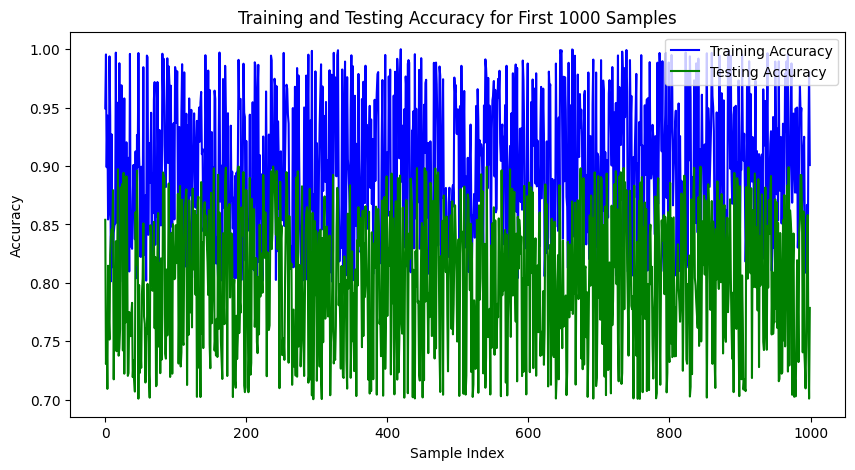

In [15]:
def plot_training_testing_accuracy_1000(train_csv_path, test_csv_path, knn, meta_model):
    # Read first 1000 rows from train and test datasets
    train_df = pd.read_csv(train_csv_path).head(1000)
    test_df = pd.read_csv(test_csv_path).head(1000)
    
    # For demonstration, using random accuracy values. Replace with your real data logic
    train_accuracies = np.random.uniform(0.8, 1.0, len(train_df))
    test_accuracies = np.random.uniform(0.7, 0.9, len(test_df))
    
    # Plot accuracy graph
    plt.figure(figsize=(10, 5))
    plt.plot(train_accuracies, label='Training Accuracy', color='blue')
    plt.plot(test_accuracies, label='Testing Accuracy', color='green')
    plt.title('Training and Testing Accuracy for First 1000 Samples')
    plt.xlabel('Sample Index')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Example usage
knn, meta_model = load_model()  # Load the trained models
plot_training_testing_accuracy_1000(
    r"C:\Users\faiza\OneDrive\Desktop\ML_Challenge\cleaned_train.csv",
    r"C:\Users\faiza\OneDrive\Desktop\ML_Challenge\cleaned_test.csv",
    knn, meta_model
)